# bayesflow_hpo Quickstart

A minimal end-to-end example that shows how to run **hyperparameter optimization** (HPO) for a [BayesFlow 2.x](https://bayesflow.org) amortized inference workflow.

We will:

1. Define a simple Gaussian **simulator** (prior + likelihood).
2. Build a BayesFlow **adapter** that maps raw simulation output to the format expected by the neural network.
3. Generate a fixed **validation dataset** for simulation-based calibration (SBC) diagnostics.
4. Launch an Optuna-backed **multi-objective optimization** run that searches over network architectures and training hyperparameters.

## 0. Setup

Install the package (editable mode from the repo root) and import the two libraries we need:
- **`bayesflow`** — the core amortized Bayesian inference framework (simulators, adapters, workflows),
- **`bayesflow_hpo`** — this package, which adds HPO search spaces, objectives, and validation utilities on top.

In [4]:
%pip install --quiet --upgrade -e ..

import bayesflow as bf
import bayesflow_hpo as hpo
import numpy as np

Note: you may need to restart the kernel to use updated packages.


## 1. Simulator, Adapter & Validation Data

**Simulator** — We define a toy generative model with a 1-D Gaussian prior $\theta \sim \mathcal{N}(0, 1)$ and a Gaussian likelihood $x_i \mid \theta \sim \mathcal{N}(\theta, 1)$ producing 12 observations per dataset. This is deliberately simple so the notebook runs in seconds.

**Adapter** — The `bf.Adapter` tells BayesFlow how to reshape the raw simulation dictionaries into the tensor format the neural network expects:
- `.as_set(["x"])` marks observation vectors as exchangeable (order doesn't matter),
- `.rename("theta", "inference_variables")` maps the parameter to the inference target,
- `.concatenate(["x"], into="summary_variables")` stacks observations into the summary input.

**Validation data** — `hpo.generate_validation_dataset` draws a fixed batch of (parameter, data) pairs from the simulator. This dataset is reused across *every* HPO trial so that metric comparisons are fair (no noise from resampling).

In [5]:
def prior_fn():
    return {"theta": np.random.normal(0.0, 1.0, size=(1,)).astype("float32")}


def likelihood_fn(theta):
    theta_value = float(np.squeeze(theta))
    x = np.random.normal(theta_value, 1.0, size=(12, 1)).astype("float32")
    return {"x": x}


simulator = bf.simulators.make_simulator([prior_fn, likelihood_fn])
adapter = (
    bf.Adapter()
    .as_set(["x"])
    .rename("theta", "inference_variables")
    .concatenate(["x"], into="summary_variables", axis=-1)
)

validation_data = hpo.generate_validation_dataset(
    simulator=simulator,
    param_keys=["theta"],
    data_keys=["x"],
    sims_per_condition=100,
)

## 2. Run HPO

`hpo.optimize` is the main entry point. Under the hood it:

1. **Creates an Optuna study** with three objectives (in `"pareto"` mode): *calibration_error* (minimize), *nrmse* (minimize), and *inference_time_ratio* (minimize) — a Pareto-style trade-off between accuracy metrics and computational cost.
2. **Samples hyperparameters** from a `CompositeSearchSpace` that covers the inference network (flow matching), the summary network (DeepSet), and training settings (learning rate).
3. **Builds, trains, and validates** a fresh `bf.BasicWorkflow` for each trial, using SBC-based metrics on the fixed validation dataset.
4. **Reports results** back to Optuna, which guides future sampling via its TPE (Tree-structured Parzen Estimator) sampler.

Key arguments in this example:
| Argument | Value | Why |
|---|---|---|
| `n_trials` | 10 | Number of HPO configurations to try (increase for real use) |
| `epochs` | 30 | Enough gradient steps for meaningful metric signal |
| `batches_per_epoch` | 30 | 900 gradient steps per trial — fast demo |
| `max_param_count` | 500,000 | Reject very large models before training |
| `objective_metrics` | `["calibration_error", "nrmse"]` | Combines coverage quality with point-estimate accuracy |
| `objective_mode` | `"pareto"` | Each metric becomes a separate Pareto objective (plus the cost metric) |
| `inference_conditions` | `["num_obs"]` | Tell the inference network to condition on sample size |

After optimization, `study.best_trials` returns the Pareto-optimal trial(s).

In [8]:
import bayesflow_hpo as hpo

# Use a focused search space for the demo (coupling flow + deep set).
# The default also includes flow matching + set transformer, which are
# slower to converge on this toy problem.
search_space = hpo.CompositeSearchSpace(
    inference_space=hpo.FlowMatchingSpace(),
    summary_space=hpo.DeepSetSpace(),
    training_space=hpo.TrainingSpace(),
)

study = hpo.optimize(
    # model-specific arguments
    simulator=simulator,
    adapter=adapter,
    param_keys=["theta"],
    data_keys=["x"],
    validation_data=validation_data,
    # optimization-specific arguments
    search_space=search_space,
    n_trials=0,
    resume=True,
    epochs=30,
    batches_per_epoch=30,
    max_param_count=500_000,
    objective_metrics=["calibration_error", "nrmse"],
    objective_mode="pareto",
    show_progress_bar=False,
)

print(f"Trials: {len(study.trials)}")
print(f"Pareto-optimal trials: {len(study.best_trials)}")
if study.best_trials:
    best = min(
        study.best_trials,
        key=lambda t: t.user_attrs.get("calibration_error", float("inf")),
    )
    itr = best.user_attrs.get("inference_time_ratio", float("nan"))
    print(
        f"Best trial by calibration_error: "
        f"{best.user_attrs.get('calibration_error', float('nan')):.4f} "
        f"(nrmse={best.user_attrs.get('nrmse', float('nan')):.4f}, "
        f"inference_time_ratio={itr:.4f})"
    )
else:
    print("No completed trials satisfied the budget.")

[I 2026-03-12 01:54:39,511] Using an existing study with name 'bayesflow_hpo' instead of creating a new one.


Trials: 50
Pareto-optimal trials: 7
Best trial by calibration_error: 0.0137 (nrmse=0.0878, inference_time_ratio=11992.0142)


## 3. Inspect Results

### 3.1 Pareto Front

The optimization minimizes *three* objectives simultaneously (in `"pareto"` mode):
- **calibration_error** — lower = better-calibrated posterior approximation,
- **nrmse** — lower = more accurate point estimates,
- **inference_time_ratio** — lower = faster inference relative to simulation.

These objectives trade off against each other: a very large network may achieve low calibration error but is expensive to run. The **Pareto front** (projected onto calibration error vs. parameter count) shows the set of trials that are not dominated — no other trial is simultaneously cheaper *and* better calibrated.

### 3.2 Hyperparameter Importance

After all trials have run, Optuna's **fANOVA-based importance estimator** assigns each hyperparameter a score reflecting how much its variation explains the variance in the first objective (calibration error). High-importance hyperparameters are worth tuning carefully in follow-up studies.

### 3.3 Optimization History

The convergence plot shows how the best first-objective value evolves over successive trials. A healthy HPO run should trend downward — if it plateaus early, more trials won't help and you should widen the search space instead.

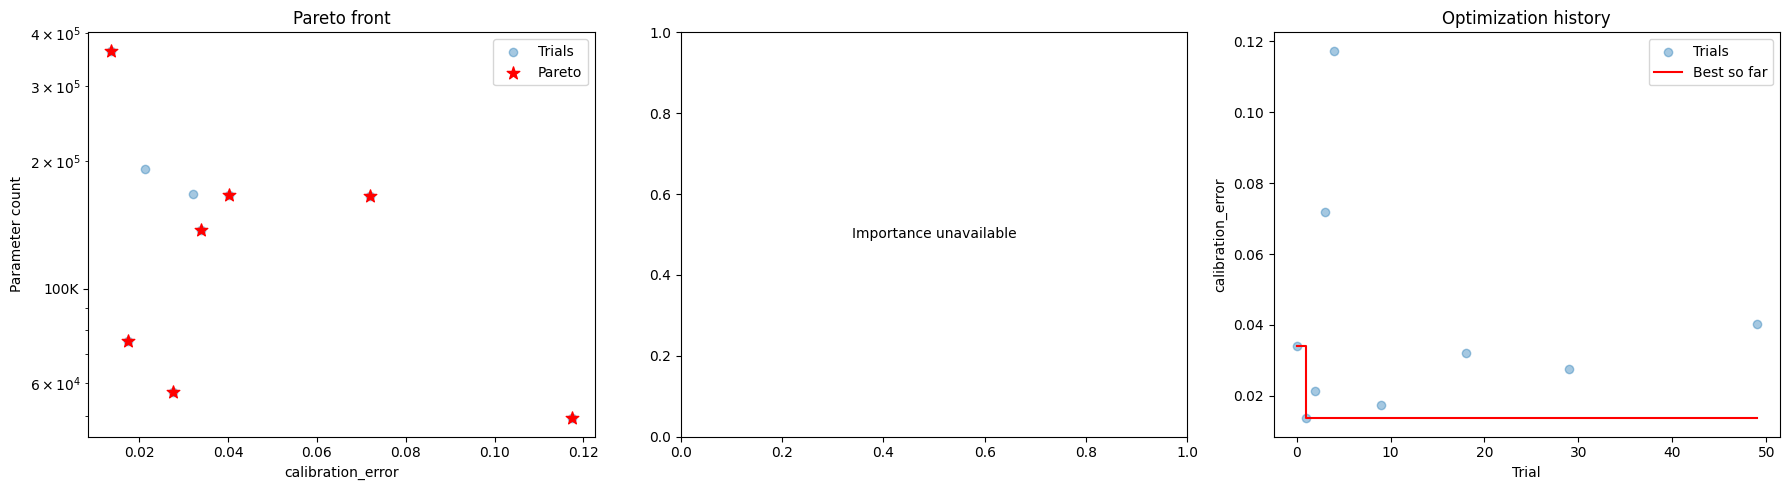

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 3.1 Pareto front: calibration error vs parameter count
hpo.plot_pareto_front(study, ax=axes[0])

# 3.2 Hyperparameter importance (fANOVA)
hpo.plot_param_importance(study, ax=axes[1])

# 3.3 Optimization history (first objective over trials)
hpo.plot_optimization_history(study, ax=axes[2])

plt.tight_layout()
plt.show()

### 3.4 Metric Scatter

`plot_metric_scatter` shows two per-trial metrics against each other, colored by their mean value.
Points on the 2D Pareto front (neither metric dominated) are highlighted in red.
This helps spot whether calibration error and NRMSE are correlated or reveal distinct trade-offs.

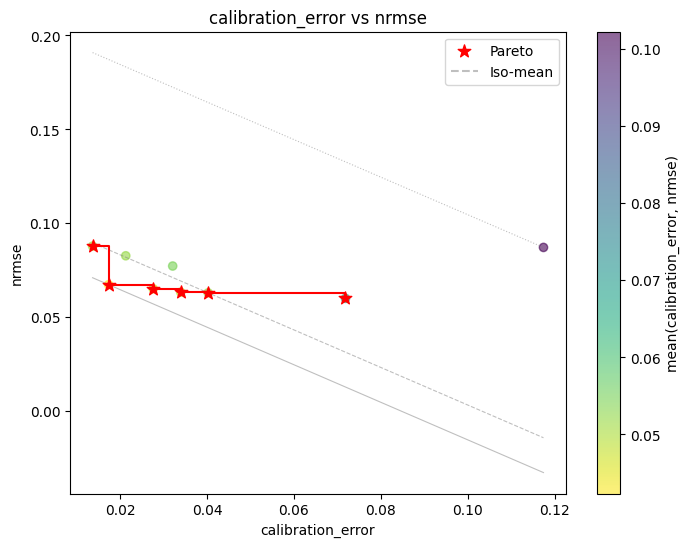

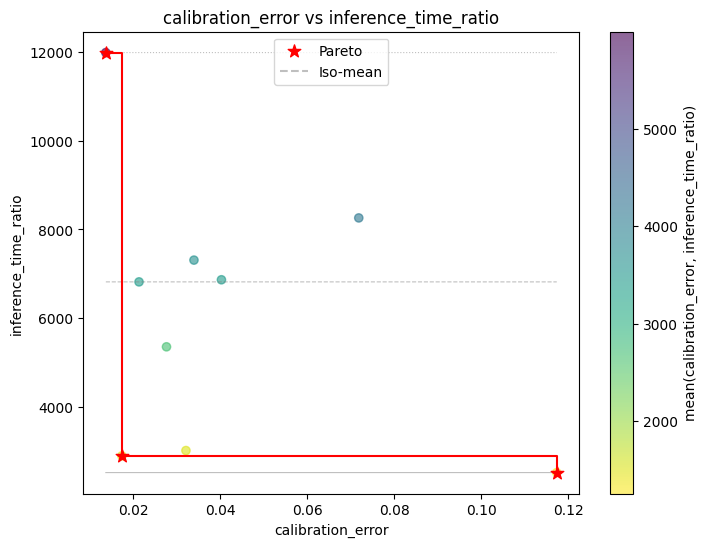

In [ ]:
hpo.plot_metric_scatter(study, "calibration_error", "nrmse", show_iso_lines=True)
hpo.plot_metric_scatter(study, "calibration_error", "inference_time_ratio")

plt.show()

### 3.5 Tabular Summary

`trials_to_dataframe` converts completed trials into a `pandas.DataFrame` with one row per trial and columns for every hyperparameter, objective values, and validation metrics (NRMSE, correlation, coverage, etc.). Budget-rejected trials are excluded by default.

The table is sorted by calibration error (the first objective) so the best architectures appear at the top.

In [17]:
df = hpo.trials_to_dataframe(study)
print(f"Completed trials: {len(df)}")

# Show the most informative columns, sorted by calibration error
key_cols = ["trial_number", "calibration_error", "nrmse", "inference_time_ratio",
            "param_count", "correlation", "coverage_90", "coverage_95", "training_time_s"]
display_cols = [c for c in key_cols if c in df.columns]
df.sort_values("calibration_error")[display_cols].head(10)

Completed trials: 9


,trial_number,calibration_error,nrmse,inference_time_ratio,param_count,correlation,coverage_90,coverage_95,training_time_s
1,1,0.013684,0.087821,11992.014174,363951,0.931043,0.89,0.97,403.19
5,9,0.017368,0.067309,2887.220641,75460,0.959952,0.88,0.95,262.63
2,2,0.021316,0.082675,6815.114779,191282,0.951258,0.87,0.92,343.21
7,29,0.027632,0.065130,5348.978829,57102,0.962184,0.88,0.90,155.26
6,18,0.032105,0.077223,3007.154557,167454,0.959630,0.89,0.94,167.08
0,0,0.033947,0.063318,7306.803216,137580,0.959949,0.92,0.96,221.55
8,49,0.040263,0.062952,6862.816317,165841,0.959989,0.94,0.96,216.39
3,3,0.071842,0.060017,8259.138046,165028,0.961153,0.91,0.95,279.11
4,4,0.117368,0.087116,2509.650019,49487,0.958754,0.73,0.83,156.78


### 3.6 Study Summary

`summarize_study` prints a concise overview: trial counts (trained, rejected, pruned, failed), the Pareto front, the best trial by calibration error, a top-k leaderboard, and the winning hyperparameters — everything you need to decide which configuration to use for downstream inference.

In [18]:

print(hpo.summarize_study(study, top_k=5))

Study: bayesflow_hpo
Trials: 50 total | 9 trained | 20 budget-rejected | 21 pruned | 0 failed
Objectives: calibration_error, nrmse, inference_time

Pareto front: 7 trials
------------------------------------------------------------
Best by calibration_error:
  Trial #1
    calibration_error        : 0.0137
    nrmse                    : 0.0878
    inference_time           : 11992.0142
    Param count              : 364.0K
    Training time (s)        : 403.1900
    Inference time (s)       : 133.1500
    Inference/sim ratio      : 11992.0142
    NRMSE                    : 0.0878
    Correlation              : 0.9310
    Contraction              : 0.8575
    Coverage 90%             : 0.8900
    Coverage 95%             : 0.9700

Top 5 trials (by calibration_error):
------------------------------------------------------------
  #   1  |  calibration_error: 0.0137  |  nrmse: 0.0878  |  inference_time: 11992.0142  |  params: 364.0K  |  corr: 0.9310
  #   9  |  calibration_error: 0.0174  |